In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.maxcut import MaxCut
from src.simulator import QuimbSimulator
from src.optimizer import COBYLA, SMO
from src.lvqe import LayerVQE
from collections import Counter

In [2]:
SEED=562
N_LAYERS=2
K_PER_LAYER=10
K_FINAL=30

SIMULATOR=SMO

num_nodes = 32
def get_random_graph(N: int, seed: int = SEED, plot=False):
    assert N % 2 == 0
    while True:
        G = nx.random_regular_graph(3, num_nodes)
        if nx.is_connected(G):
            if plot:
                plt.figure(figsize=(8, 6))
                pos = nx.spring_layout(G, seed=seed)
                nx.draw(G, pos, with_labels=True, node_color='lightblue',
                    node_size=400, font_size=10, font_weight='bold')
                plt.title(f"Random regular graph G(k=3, N={G.number_of_nodes()}): {G.number_of_edges()} edges")
                plt.show()
            return G
        else:
            seed += 1
    return None

G = get_random_graph(num_nodes, seed=SEED, plot=False)

np.random.seed(SEED)

In [3]:
problem = MaxCut(G, seed=SEED)
print(f"\nn_qubits: {problem.num_qubits}")
print(f"n_terms: {len(problem.hamiltonian_terms)}\n")

sim = QuimbSimulator()

best_known = problem.best_known_value

print(f"best known cut value : {best_known}")
print(f"corresponding energy: {problem.cut_to_energy(best_known)}")



n_qubits: 31
n_terms: 48

best known cut value : 42.0
corresponding energy: 18.0


Starting L-VQE: 2 layers, 10 iter/layer, 30 final iter
Mode: finite sampling

Layer 0: 



SMO: 100%|██████████████████████| 10/10 [01:42<00:00, 10.21s/it, best_E=+4.0091]


layer 0: energy=+4.0091, approx_ratio=+0.6669

Layer 1 — 10 iterations (before convergence)


SMO: 100%|██████████████████████| 10/10 [01:42<00:00, 10.24s/it, best_E=+4.1149]


layer 1: energy=+4.1149, approx_ratio=+0.6694

Final layer — 30 iterations (final)


SMO: 100%|█████████████████████| 30/30 [05:07<00:00, 10.25s/it, best_E=+12.8519]

layer 2: energy=+12.8519, approx_ratio=+0.8774

Final approximation ratio: 0.8774


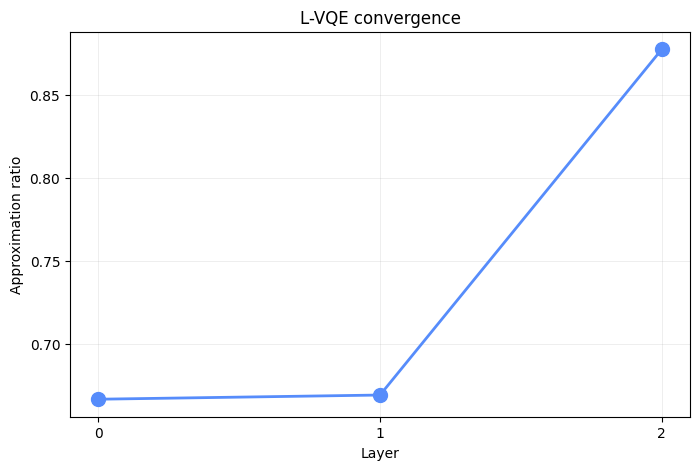

In [4]:
# run L-VQE
lvqe = LayerVQE(
    problem=problem,
    simulator=sim,
    optimizer_class=SIMULATOR,
    n_layers=N_LAYERS,
    k_per_layer=K_PER_LAYER,
    k_final=K_FINAL,
    use_sampling=True,
    record_loss=True
)

result = lvqe.run()

print(f"\nFinal approximation ratio: {result['final_approx_ratio']:.4f}")

# plot the convergence
plt.figure(figsize=(8, 5))
plt.plot(result['history']['layer'], result['history']['approx_ratio'],
         'o-', linewidth=2, markersize=10)
plt.xlabel('Layer')
plt.ylabel('Approximation ratio')
plt.title('L-VQE convergence')
plt.grid(True, alpha=0.3)
plt.xticks(result['history']['layer'])
plt.show()

[[np.float64(0.12800000000000009), np.float64(0.12803530369293378), np.float64(0.9963889701384824), np.float64(1.0336661357177712), np.float64(1.2163922580325506), np.float64(2.032243435311951), np.float64(2.593402894979998), np.float64(2.8250607946825337), np.float64(3.629508705224863), np.float64(3.707299679413243), np.float64(4.009112529169142)], [np.float64(4.031999999999959), np.float64(4.045998585248588), np.float64(4.054057106708824), np.float64(4.054266127834061), np.float64(4.069766693672289), np.float64(4.070425277339888), np.float64(4.091742913381655), np.float64(4.097184769391348), np.float64(4.097197530503378), np.float64(4.107018699325714), np.float64(4.114913477310641)], [np.float64(4.003499999999959), np.float64(4.005556638697201), np.float64(4.006277728808993), np.float64(4.007417313115917), np.float64(4.008030077662276), np.float64(4.008030294476596), np.float64(4.008174045675227), np.float64(4.012970499250995), np.float64(4.012995048772929), np.float64(4.014197214581

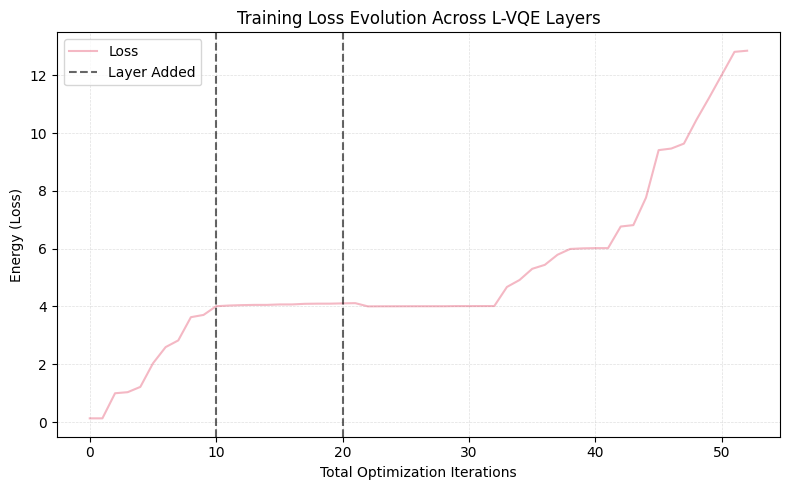

In [5]:
plt.figure(figsize=(8, 5))

optimizer_loss = result['history']['optimizer_loss']
continuous_loss = np.concatenate(optimizer_loss)
plt.plot(continuous_loss, color='crimson', alpha=0.3, linewidth=1.5, label='Loss')

transition_points = [K_PER_LAYER * layer for layer in range(1,N_LAYERS+1)]

for idx, pt in enumerate(transition_points):
    plt.axvline(x=pt, color='black', linestyle='--', alpha=0.6,
                label='Layer Added' if idx == 0 else "")

plt.xlabel('Total Optimization Iterations')
plt.ylabel('Energy (Loss)')
plt.title(f'Training Loss Evolution Across L-VQE Layers')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [8]:
bitstrings = sim.get_most_frequent_assignments(result['final_params'], result['final_ansatz'], problem=problem)

for (assignment, proba) in bitstrings:
    print(f"Assignment {assignment} (proba: {proba:.1f})")
    cut_value = problem.evaluate(assignment)
    print(f"Corresponding cut value: {cut_value}")
    print(f"Corresponding energy: {problem.cut_to_energy(cut_value)}")

Assignment [0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0] (proba: 21.6)
Corresponding cut value: 39.0
Corresponding energy: 15.0
Assignment [0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0] (proba: 16.2)
Corresponding cut value: 36.0
Corresponding energy: 12.0
Assignment [0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1] (proba: 15.3)
Corresponding cut value: 38.0
Corresponding energy: 14.0
Assignment [0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1] (proba: 12.1)
Corresponding cut value: 35.0
Corresponding energy: 11.0
Assignment [0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0] (proba: 3.4)
Corresponding cut value: 38.0
Corresponding energy: 14.0
